# Model Development & Tracking
## Stage 3 · baseline + advanced models, MLflow tracking & registry  <font color="red">[30 marks]</font>

- Each stage lists its **sub-tasks as a checklist**
- Complete every `# TODO`; implement the training logic in `src/train.py` (metrics helper provided in `src/evaluate.py`) and call it here.

**File ownership** — 
- *Provided:* `config.py`, `src/evaluate.py`
- *Provided to extend:* `src/train.py`. 
- *You create:* the cells below.

- **3.1.1 — Logistic Regression baseline trained (Pipeline, imbalance handled) [3]** — `LogisticRegression(class_weight='balanced')` as a full Pipeline (preprocess + classify), fit on train.
- **3.1.2 — Baseline evaluated on validation [2]** — report imbalance-aware validation metrics (ROC-AUC / PR-AUC / recall).

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import json, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
import config as cfg
from src.train import train_and_log
best, test_metrics = train_and_log()
print('best model:', best)
test_metrics

2026/06/24 18:37:46 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/24 18:37:46 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2026/06/24 18:37:46 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment 

[logreg_baseline] val ROC-AUC=0.6454 PR-AUC=0.165 recall=0.5448


2026/06/24 18:38:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[xgboost_advanced] val ROC-AUC=0.6552 PR-AUC=0.1808 recall=0.49

BEST: xgboost_advanced | test {'roc_auc': 0.6385, 'pr_auc': 0.171, 'f1': 0.2236, 'recall': 0.4845, 'precision': 0.1454, 'accuracy': 0.6983} | cm {'tn': 9165, 'fp': 3575, 'fn': 647, 'tp': 608}


2026/06/24 18:38:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/24 18:38:05 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
Registered model 'readmission_classifier' already exists. Creating a new version of this model...
2026/06/24 18:38:05 WARNING mlflow.tracking._model_registry.fluent: Run with id 80a98dbe0aec4798b4a6f2f1940543a2 has no artifacts at artifact path 'model', registering model based on models:/m-310d9f48e95d486da8620dacfd471ebf instead
Created version '3' of model 'readmission_classifier'.


saved best_model.pkl, metrics.json, reference_sample.csv (registered readmission_classifier v3 -> @production)
best model: xgboost_advanced


{'roc_auc': 0.6385,
 'pr_auc': 0.171,
 'f1': 0.2236,
 'recall': 0.4845,
 'precision': 0.1454,
 'accuracy': 0.6983}

## Stage 3.2 — Advanced Model (XGBoost) <font color="red">[8 marks]</font>
- **3.2.1 — XGBoost trained (Pipeline, `scale_pos_weight` imbalance handled) [5]** — XGBoost with `scale_pos_weight = neg/pos` as a full Pipeline, fit on train.
- **3.2.2 — Advanced model evaluated on validation [3]** — report the same validation metrics for comparison with the baseline.

## Stage 3.3 — Model Evaluation & Comparison <font color="red">[5 marks]</font>
- **3.3.1 — Imbalance-aware metrics + model selection [3]** — ROC-AUC, PR-AUC, recall, precision, F1 for both models in a comparison table; select on ROC-AUC.
- **3.3.2 — Plots + interpretation (why accuracy misleads) [2]** — ROC + confusion plots; explain why accuracy is misleading at ~9% prevalence.

In [ ]:
m = json.loads((cfg.ARTIFACT_DIR/'metrics.json').read_text())
pd.DataFrame(m['validation']).T[['roc_auc','pr_auc','recall','precision','f1']]

,roc_auc,pr_auc,recall,precision,f1
logreg_baseline,0.6454,0.1650,0.5448,0.1401,0.2229
xgboost_advanced,0.6552,0.1808,0.4900,0.1488,0.2283


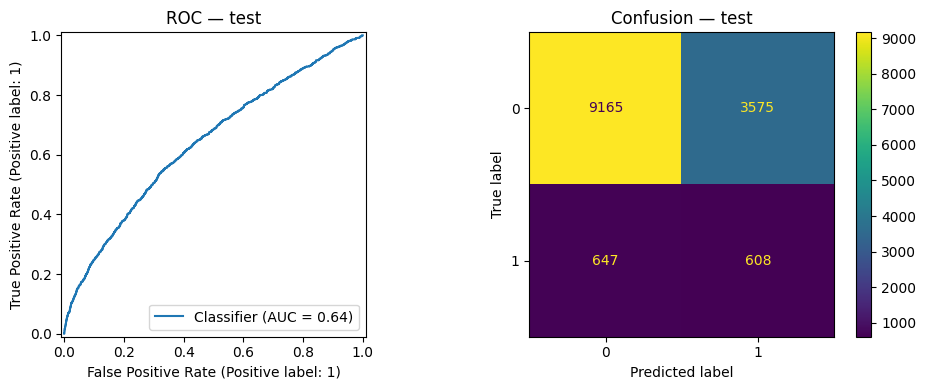

In [ ]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from src import data_prep as dp
Xtr, Xv, Xte, ytr, yv, yte = dp.get_splits()
model = joblib.load(cfg.ARTIFACT_DIR/'best_model.pkl')
prob = model.predict_proba(Xte)[:,1]; pred = (prob>=0.5).astype(int)
fig, ax = plt.subplots(1,2, figsize=(10,4))
RocCurveDisplay.from_predictions(yte, prob, ax=ax[0]); ax[0].set_title('ROC — test')
ConfusionMatrixDisplay.from_predictions(yte, pred, ax=ax[1]); ax[1].set_title('Confusion — test')
plt.tight_layout(); plt.savefig(cfg.ARTIFACT_DIR/'model_eval.png', dpi=90); plt.show()

## Stage 3.4 — MLflow Experiment Tracking <font color="red">[7 marks]</font>

- **3.4.1 — Both runs logged with params + metrics + model [4]** — set tracking URI + experiment; for each model log params, metrics and the model artefact.
- **3.4.2 — Runs compared (search_runs table) [3]** — compare the runs with `mlflow.search_runs(...)` and state the selection criterion.

In [ ]:
import mlflow
mlflow.set_tracking_uri(cfg.MLFLOW_TRACKING_URI)
exp = mlflow.get_experiment_by_name(cfg.MLFLOW_EXPERIMENT)
runs = mlflow.search_runs([exp.experiment_id])
runs[[c for c in runs.columns if c in ('tags.mlflow.runName','metrics.val_roc_auc','metrics.val_pr_auc','metrics.val_recall')]].head()

,metrics.val_recall,metrics.val_pr_auc,metrics.val_roc_auc,tags.mlflow.runName
0,0.4900,0.1808,0.6552,xgboost_advanced
1,0.5448,0.1650,0.6454,logreg_baseline
2,0.4721,0.1769,0.6572,xgboost_advanced
3,0.5428,0.1710,0.6537,logreg_baseline
4,0.4721,0.1769,0.6572,xgboost_advanced


## Stage 3.5 — Model Registry & Promotion <font color="red">[5 marks]</font>

- **3.5.1 — Best model registered in the MLflow Model Registry [2]** — `mlflow.register_model` for the best model.
- **3.5.2 — Promotion to production alias + version history [3]** — promote to the `production` alias and show the version history.

In [ ]:
from mlflow import MlflowClient

client = MlflowClient(cfg.MLFLOW_TRACKING_URI)

versions = client.search_model_versions(
    f"name='{cfg.REGISTERED_MODEL}'"
)

for v in versions[-3:]:
    print(
        f'version {v.version} | run {v.run_id[:8]} | aliases {list(v.aliases)}'
    )

version 3 | run 80a98dbe | aliases []
version 2 | run 2b0eea92 | aliases []
version 1 | run 8be23254 | aliases []


### ✍️ Findings
*TODO: which model won and why? Why is accuracy misleading here?*